<center><span style="font-size:40px;"><b>NUTS vs HMC on GAUSSIAN 250D POSTERIOR</b></span></center>

In [10]:
import numpy as np
import pymc as pm
import arviz as az

import matplotlib.pyplot as plt
import pandas as pd
import time

from scipy.stats import wishart
from scipy.linalg import solve_triangular

# Set random seed for reproducibility
rng = np.random.default_rng(12345)

---

---

---

---

# PAPER STATEMENTS

"In these experiments the target distribution was a **zero-mean** 250-dimensional multivariate
normal with known precision matrix"

"NUTS was run with
**δ = 0.5 for 2,000 iterations, with the first 1,000 iterations being used as warmup and to adapt ε**." (qualitative testing)

**NUTS’s best performance seems to occur around δ = 0.6, but
does not seem to depend strongly on δ within the range δ ∈ [0.45, 0.65]. δ = 0.6 therefore
seems like a reasonable default value for NUTS.**

"In all experiments the **dual averaging parameters were set to γ = 0.05, t0 = 10, and κ = 0.75**."

"we compute **ESS separately for each dimension and report the minimum ESS across all dimensions**, since we want our samplers to effectively explore all dimensions of the target distribution. For each dimension we compute ESS in terms of the variance of the estimator of that dimension’s mean and second central moment (where the **estimate of the mean used to compute the second central moment is taken from a separate long run of 50,000 iterations of NUTS with δ = 0.5**), reporting whichever statistic has a lower effective sample size. We include the second central moment as well as the mean in order to measure each algorithm’s ability to estimate uncertainty."

"The matrix A was generated from a Wishart distribution with identity scale matrix and 250 degrees of freedom."

---

---

---

# WISHART DISTIRBUTION

The Wishart distribution is a probability distribution over symmetric positive-definite matrices. It serves as a multivariate generalization of the chi-squared distribution. 

If we have a $d \times d$ matrix $A$, then $A \sim \mathcal{W}_d(V, \nu)$ denotes that $A$ follows a Wishart distribution with scale matrix $V$ (a fixed positive-definite matrix) and $\nu$ degrees of freedom.

The construction of a Wishart matrix is intuitive: you sample $\nu$ independent vectors from a multivariate normal distribution $x_i \sim \mathcal{N}(0, V)$ and compute their outer product sum:

$$A = \sum_{i=1}^{\nu} x_i x_i^T$$

This resulting matrix $A$ is always symmetric and positive-definite, making it ideal for use as either a covariance matrix or a precision matrix (the inverse of a covariance matrix). The parameter $V$ defines the base structure or shape of the correlations, while the degrees of freedom $\nu$ control the stability. A larger $\nu$ makes the matrix more stable and closer to $\mathbb{E}[A] = \nu V$, whereas a smaller $\nu$ introduces more randomness. So $V$ is the "average shape" of $A$, and $A$ fluctuates around $\nu V$.

$V$ is basically just a covariance matrix. This means it is symmetric: $V = V^T$, and it is positive definite: $x^T V x > 0$ for all $x \neq 0$. So you can think of $V$ as describing how variables are correlated or how large their variances are. 

For example, in $d=2$:
$$
V =
\begin{pmatrix}
1 & 0.8 \\
0.8 & 2
\end{pmatrix}
$$
means variable 1 has variance 1, variable 2 has variance 2, and they are positively correlated.

It is important to distinguish between $d$ and $\nu$:
* $d$ is the dimensionality of the vector space. It determines the size of the matrix $A$ (which is $d \times d$) and the length of the vectors $x_i$.
* $\nu$ is the number of independent samples summed together (degrees of freedom)

For the matrix $A$ to be invertible and usable as a precision matrix, we generally require $\nu \ge d$. 

In the paper they generate $A$ using:
$$
A \sim \mathcal{W}_d(I, 250)
$$
where $I$ is the identity matrix.

#### EXAMPLE and USE

Consider a low-dimensional case where $d=2$, $V=I$, and $\nu=5$. We draw five independent vectors $x_1, \dots, x_5$ from $\mathcal{N}(0, I)$. When we calculate the sum of the outer products $A = \sum_{i=1}^5 x_i x_i^T$, we obtain a random $2 \times 2$ matrix. By using this $A$ as the precision matrix in a multivariate Gaussian $\mathcal{N}(0, A^{-1})$, we create a distribution with non-trivial, random correlations even though the base vectors were sampled independently.

#### TAKEAWAY

We should think of the Wishart distribution here as a way to generate a random but valid precision matrix, and a way to create a difficult sampling problem (correlated, high-dimensional).

### EXAMPLE FOR DEBUG

In [50]:
# Set random seed for reproducibility
rng = np.random.default_rng(12345)

# Set dimensions and degrees of freedom
d = 3
nu = 10

# Define a scale matrix V (the base covariance structure)
# We use an identity matrix to start with simple variances
V = np.eye(d)

# 1. Generate a random matrix A from the Wishart distribution: A ~ W_d(V, nu)
A = wishart.rvs(df=nu, scale=V, random_state=rng)
print("Generated Wishart matrix (Precision Matrix):\n", A)

# 2. Use the inverse of A as the Covariance matrix: Sigma = A^-1
Sigma = np.linalg.inv(A)

# 3. Sample from a Multivariate Gaussian using this Covariance: theta ~ N(0, Sigma)
theta_samples = rng.multivariate_normal(mean=np.zeros(d), cov=Sigma, size=5)
print("\nSamples from the resulting Gaussian distribution:\n", theta_samples)

Generated Wishart matrix (Precision Matrix):
 [[ 8.25776055 -4.09154911  3.63149046]
 [-4.09154911  7.68714432 -3.87067377]
 [ 3.63149046 -3.87067377 12.46474234]]

Samples from the resulting Gaussian distribution:
 [[ 1.27379773  0.25824282 -0.37930323]
 [ 0.39349784  0.20008053 -0.28964818]
 [ 0.04466975  0.0400814  -0.41982407]
 [ 0.27226514 -0.60547796 -0.15806675]
 [ 0.10558614  0.15619271 -0.50406304]]


---

---

---

---

<center><span style="font-size:30px;"><b>NUTS on GAUSSIAN 250D POSTERIOR</b></span></center>

The goal is to evaluate how well an MCMC algorithm (here NUTS) can explore a high-dimensional, strongly correlated distribution.

We start by defining a target distribution directly, without generating any observed data. The distribution is a multivariate normal in $D = 250$ dimensions:

$$
p(\theta) = \mathcal{N}(0, A^{-1})
$$

where $A$ is a positive definite precision matrix. This matrix is randomly generated from a Wishart distribution $ A \sim \mathcal{W}(\nu, I)$ with $\nu = 250$ degrees of freedom and identity scale matrix. Once $A$ is fixed, the target distribution is completely specified. (There is no likelihood and no observed dataset: the distribution itself plays the role of a "posterior" for testing the sampler.)

We then use NUTS (No-U-Turn Sampler) to draw samples from this distribution. The algorithm constructs a Markov chain whose stationary distribution is $p(\theta)$. We ran 4 independent chains, each producing 2000 samples after warmup (1000 tuning samples). Therefore, the total number of collected samples is:
$$
4 \times 2000 = 8000
$$

Each sample is a vector in $\mathbb{R}^{250}$, so overall we obtained 8000 points in a 250-dimensional space, approximately distributed according to $\mathcal{N}(0, A^{-1})$.

In [51]:
# Set random seed for reproducibility
rng = np.random.default_rng(12345)


# ============================================================
# Define the target distribution
D = 250        # dimensionality of theta
df = 250       # degrees of freedom for Wishart
warmup = 1000  # tuning steps (will be discarded)
draws = 2000   # number of MCMC samples
delta = 0.6    # target acceptance rate

# ------------------------------------------------------------
# Draw precision matrix A ~ Wishart(df, I)
# This defines the multivariate Gaussian:
#     p(theta) = N(0, A^{-1})
# ------------------------------------------------------------
A = wishart.rvs(df=df, scale=np.eye(D), random_state=rng).astype(np.float64)




# ============================================================
# Define the model in PyMC

with pm.Model() as nuts_model:
    
    # Target distribution: theta ~ N(0, A^{-1})
    # In PyMC we pass the precision matrix A via 'tau'
    theta = pm.MvNormal( "theta", mu=np.zeros(D), tau=A, shape=D )

    idata_nuts = pm.sample(
        draws=draws,          # number of posterior samples
        tune=warmup,          # adaptation phase
        chains=4,
        target_accept=delta,  # controls step size adaptation
        random_seed=2026,
        progressbar=True,
        nuts_sampler="pymc",   # explicit NUTS backend        
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 99 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


In [55]:
# Diagnostics
summary_nuts = az.summary(idata_nuts, var_names=["theta"], round_to=4) # round_to simply controls the digits output
display(summary_nuts)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta[0],-0.0861,3.0782,-5.7677,5.8282,0.1159,0.0611,705.3800,1195.5269,1.0054
theta[1],-0.0393,1.9048,-3.5781,3.5994,0.0731,0.0374,679.3963,1184.6508,1.0053
theta[2],-0.0197,1.4351,-2.8970,2.4920,0.0535,0.0275,719.6572,1309.3620,1.0050
theta[3],0.0003,0.7676,-1.3454,1.5273,0.0149,0.0094,2645.0797,3920.5318,1.0014
theta[4],-0.0248,1.1542,-2.1738,2.1623,0.0369,0.0177,980.5750,1970.4140,1.0035
...,...,...,...,...,...,...,...,...,...
theta[245],0.0435,1.2994,-2.3773,2.5057,0.0415,0.0221,982.2622,1614.6913,1.0039
theta[246],0.0161,0.5784,-1.0737,1.0815,0.0101,0.0066,3272.8196,4655.0091,1.0018
theta[247],0.0080,1.1599,-2.2155,2.1398,0.0242,0.0155,2311.9271,3347.5000,1.0013
theta[248],-0.0264,1.0466,-2.0520,1.8910,0.0333,0.0179,987.8188,1687.9508,1.0044


Number of parameters with R_hat > 1.05: 0


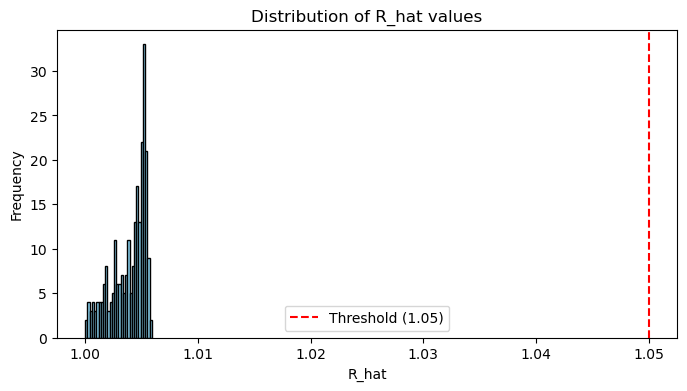

Number of parameters with ESS_bulk < 400: 0


In [56]:
# 1) Count how many rows exceed R_hat > 1.05
rhat_exceed = (summary_nuts['r_hat'] > 1.05).sum()
print(f"Number of parameters with R_hat > 1.05: {rhat_exceed}")

# 2) Plot the distribution of R_hat
plt.figure(figsize=(8, 4))
plt.hist(summary_nuts['r_hat'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(1.05, color='red', linestyle='--', label='Threshold (1.05)')
plt.title('Distribution of R_hat values')
plt.xlabel('R_hat')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 3) Check ESS (Effective Sample Size)
# Generally, we look at 'ess_bulk' or 'ess_tail'
# A common rule of thumb is ESS > 100 * number of chains (e.g., 400)
ess_threshold = 400
low_ess = (summary_nuts['ess_bulk'] < ess_threshold).sum()
print(f"Number of parameters with ESS_bulk < {ess_threshold}: {low_ess}")

# Optional: Display parameters that failed the checks
if rhat_exceed > 0:
    print("\nParameters with R_hat > 1.05:")
    print(summary_nuts[summary_nuts['r_hat'] > 1.05])

### CHECKING RESULTS

To verify that the samples follow the correct distribution, we compute the quadratic form:

$$
q = \theta^T A \theta
$$

This quantity has a well-known theoretical distribution. If $ \theta \sim \mathcal{N}(0, A^{-1})$ then we can rewrite $\theta$ as:

$$
\theta = A^{-1/2} z, \quad z \sim \mathcal{N}(0, I)
$$

Substituting into $q$:

$$
q = \theta^T A \theta = z^T A^{-1/2} A A^{-1/2} z = z^T z
$$

Therefore:

$$
q = \sum_{i=1}^{D} z_i^2
$$

which follows a chi-square distribution with $D$ degrees of freedom:

$$
q \sim \chi^2(D)
$$

This implies the following theoretical moments:

$$
\mathbb{E}[q] = D, \quad \mathrm{Var}(q) = 2D
$$

By comparing the empirical mean and variance of $q$ computed from the samples with these theoretical values, we can assess whether the sampler is correctly reproducing the target distribution.

We can then perform three main checks on the samples:
- The mean of $\theta$ should be close to zero, since $\mathbb{E}[\theta] = 0$
- The covariance of $\theta$ should be close to $A^{-1}$
- The quadratic form $q = \theta^T A \theta$ should follow a $\chi^2(D)$ distribution

If all these conditions are approximately satisfied, we can conclude that the sampler is correctly targeting the desired Gaussian distribution. This validates correctness, but not efficiency; efficiency will be evaluated later using quantities such as effective sample size and autocorrelation.

In [52]:
# ============================================================
# Check that samples match the true target distribution

theta_draws = idata_nuts.posterior["theta"].values   # Extract samples: shape = (chains, draws, D)
theta_flat = theta_draws.reshape(-1, D)              # Flatten chains → shape = (total_samples, D)

# ------------------------------------------------------------
# 1) Quadratic form: q = theta^T A theta
q = np.einsum("ni,ij,nj->n", theta_flat, A, theta_flat)
print("---- Quadratic form check ----")
print(f"mean(q) ≈ {q.mean():.2f} (theory: {D})")
print(f"var(q)  ≈ {q.var():.2f} (theory: {2*D})")

# ------------------------------------------------------------
# 2) Mean check
# Theoretical:  E[theta] = 0
# ------------------------------------------------------------
mean_emp = theta_flat.mean(axis=0)
print("\n---- Mean check ----")
print(f"average |mean_i| ≈ {np.abs(mean_emp).mean():.4e} (should be close to 0)")

# ------------------------------------------------------------
# 3) Covariance check
# Theoretical: Cov(theta) = A^{-1}
# ------------------------------------------------------------
cov_emp = np.cov(theta_flat, rowvar=False, bias=True)
cov_theory = np.linalg.inv(A)
# Relative Frobenius norm error
rel_err = np.linalg.norm(cov_emp - cov_theory, 'fro') / np.linalg.norm(cov_theory, 'fro')
print("\n---- Covariance check ----")
print(f"relative error ≈ {rel_err:.4e} (should be small)")


# NOTE: These checks validate that NUTS is correctly sampling

---- Quadratic form check ----
mean(q) ≈ 249.94 (theory: 250)
var(q)  ≈ 497.56 (theory: 500)

---- Mean check ----
average |mean_i| ≈ 3.3212e-02 (should be close to 0)

---- Covariance check ----
relative error ≈ 2.1930e-02 (should be small)


/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='theta\n0'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n1'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n2'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n3'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n4'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n5'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n6'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='theta\n0', ylabel='theta\n7'>,
        <Axes: xlabel='theta\n1'>, <Axes: xlabel='theta\n2'>,
        <Axes: xlabel='theta\n3'>, <Axes: xlabel='theta\n4'>,
        <Axes: xlabel='t

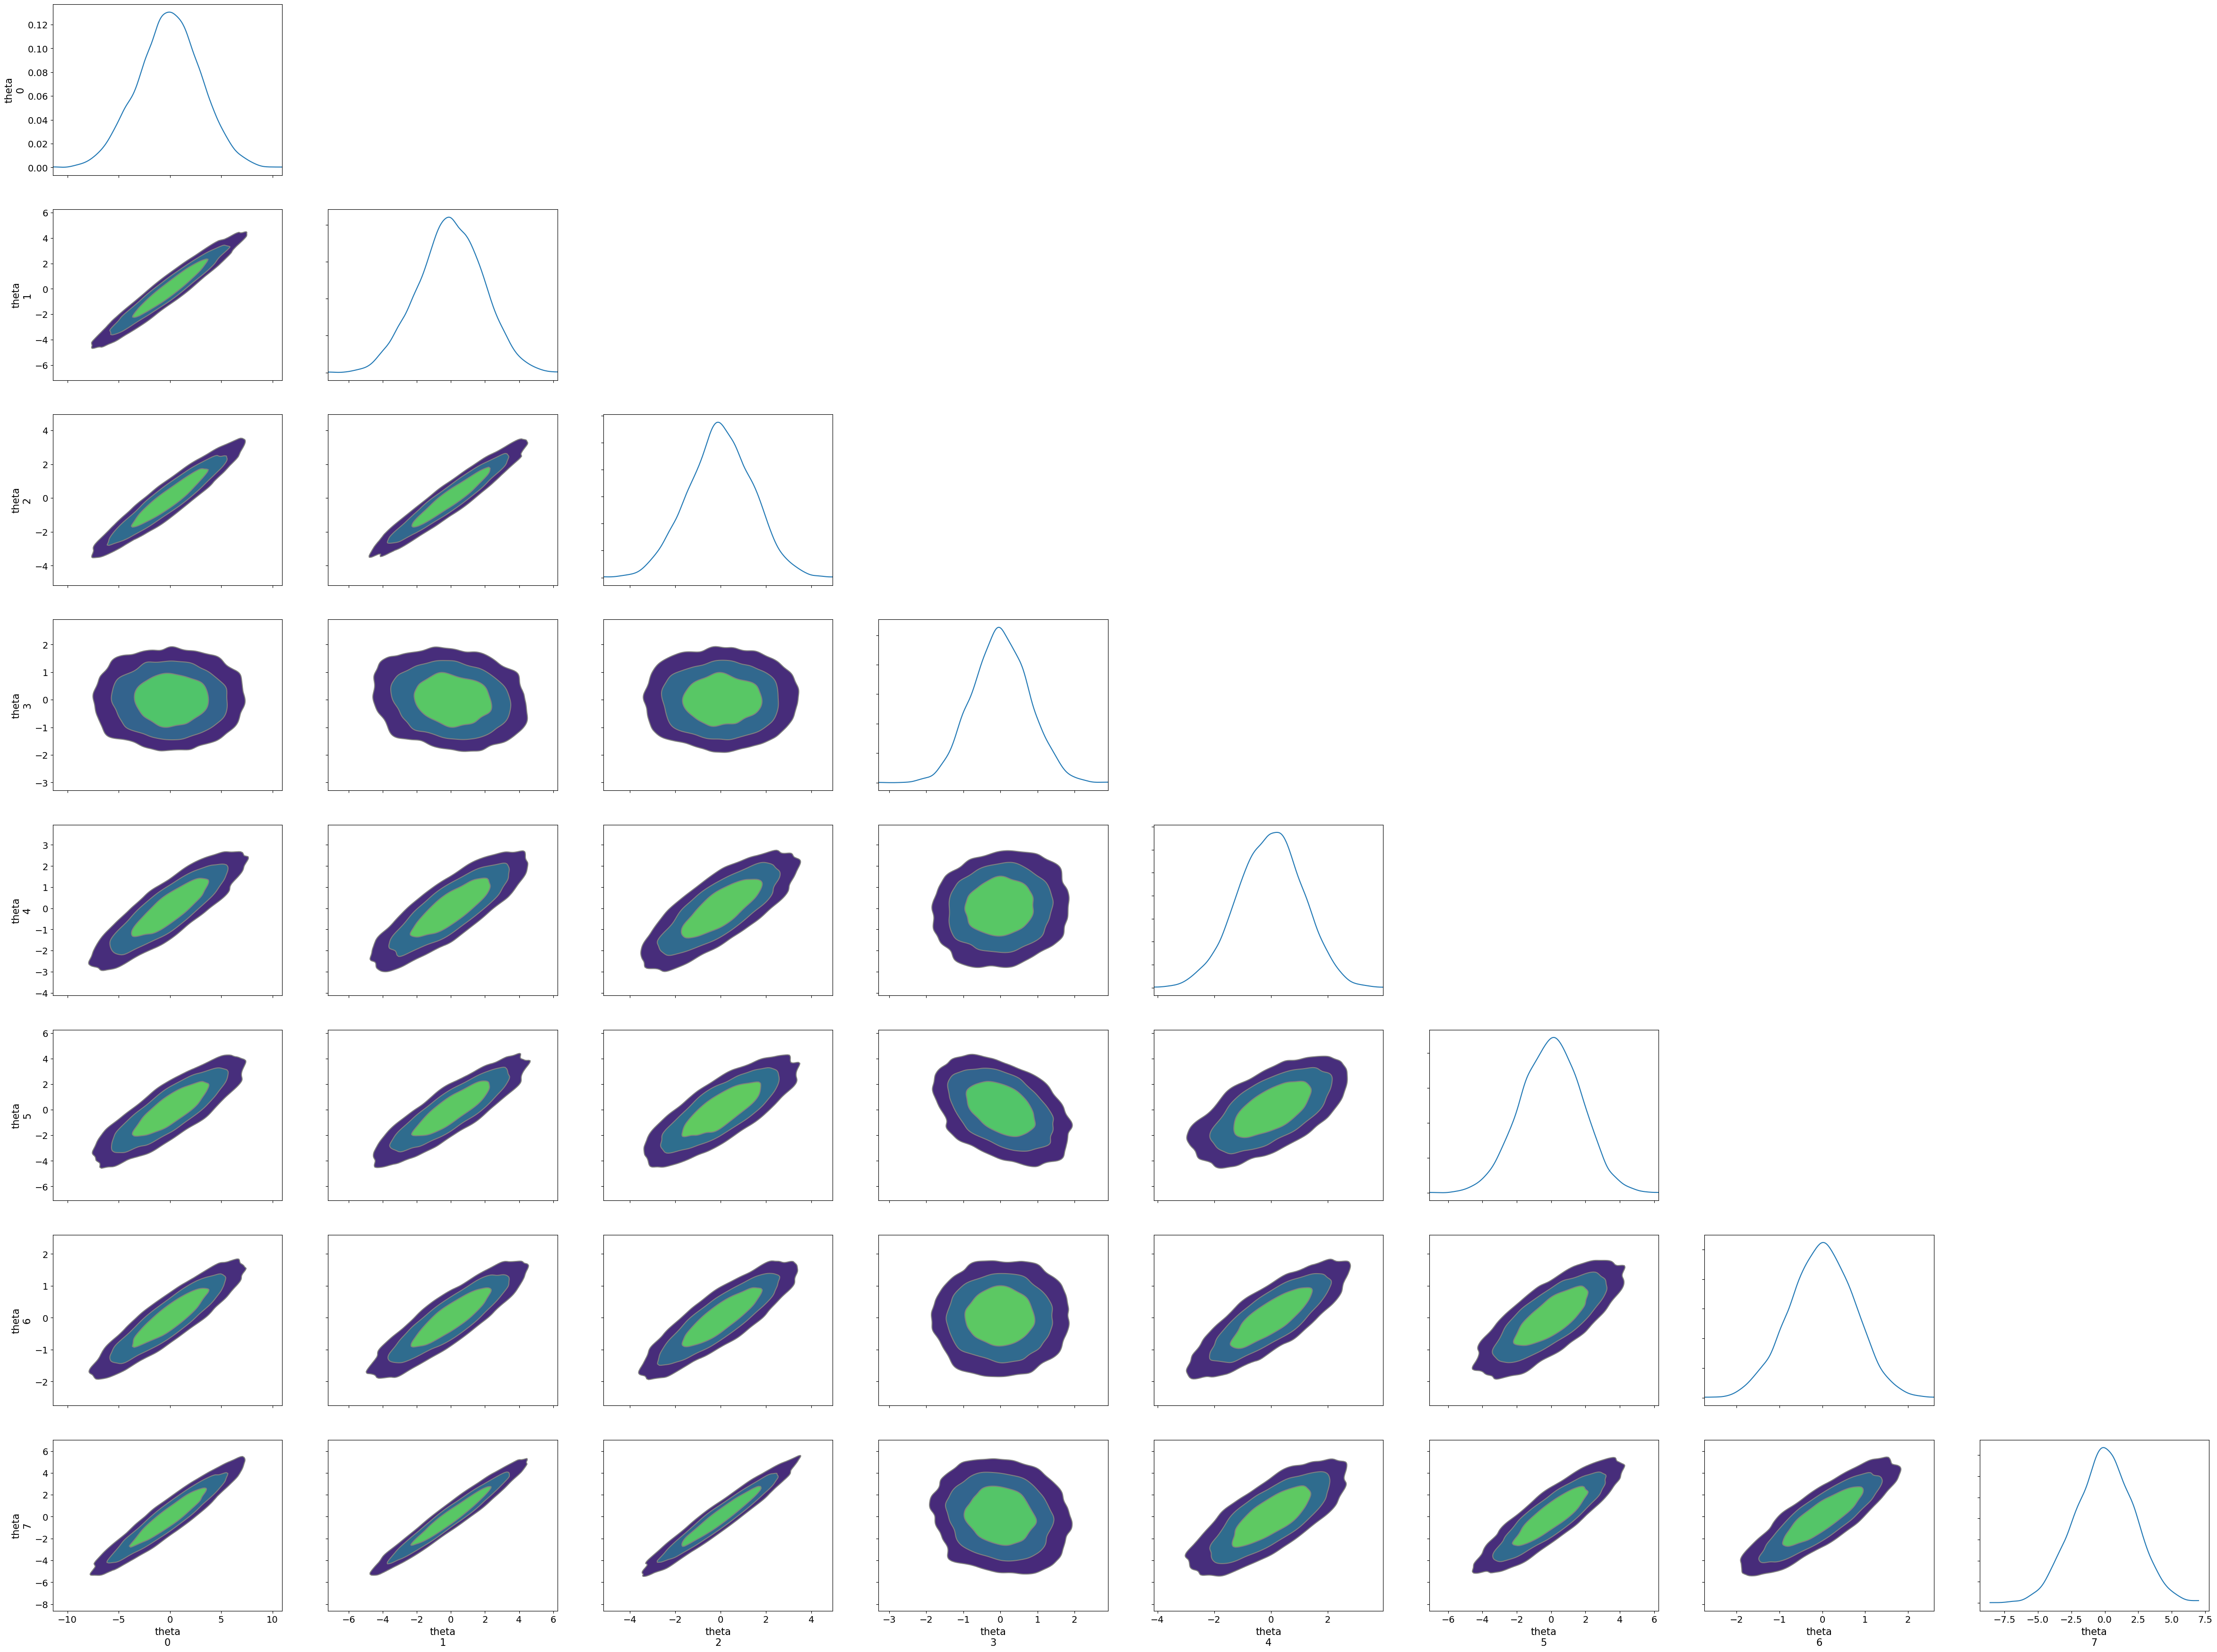

In [54]:
az.plot_pair(idata_nuts, var_names=["theta"], kind="kde", marginals=True)

I got these warnings:

Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.

Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.

Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.

Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details

In order to replicate the paper, I can increase the tree depth. If, instead, I just want a better sampling, I can increase the target acceptance rate.

In [8]:
with pm.Model() as model:
    theta_p = pm.MvNormal("theta_p", mu=np.zeros(D), tau=A, shape=D)  # tau = precision

    idata_p = pm.sample(
        draws = N,
        tune = warmup,
        chains = 4,
        target_accept = delta,
        random_seed = 2026,
        progressbar = True,
        nuts_sampler = "pymc",
        max_treedepth = 14
    )

theta_draws_p = idata_p.posterior["theta_p"].values  # shape (chains, draws, D)
theta_flat_p = theta_draws_p.reshape(-1, D)

q_p = np.einsum("ni,ij,nj->n", theta_flat_p, A, theta_flat_p)

print("mean q (theory D):", q_p.mean(), f"({D})")
print("var  q (theory 2D):", q_p.var(), f"({2*D})")

mean_emp_p = theta_flat_p.mean(axis=0)
print("mean abs avg:", np.abs(mean_emp_p).mean())

cov_emp_p = np.cov(theta_flat_p, rowvar=False, bias=True)
rel_err_p = np.linalg.norm(cov_emp - cov_theory_p, 'fro') / np.linalg.norm(cov_theory, 'fro')
print("rel cov error:", rel_err_p)

mean q (theory D): 250.13076877923928 (250)
var  q (theory 2D): 522.8773425110643 (500)


Instead, for better performance

In [ ]:
with pm.Model() as model:
    theta = pm.MvNormal("theta", mu=np.zeros(D), tau=A, shape=D)  # tau = precision

    idata = pm.sample(
        draws = N,
        tune = warmup,
        chains = 4,
        target_accept = 0.9,
        random_seed = 2026,
        progressbar = True,
        nuts_sampler = "pymc",
        init="adapt_full",
        max_treedepth = 12
    )

In [ ]:
# Checking results

theta_draws = idata.posterior["theta"].values  # shape (chains, draws, D)
theta_flat = theta_draws.reshape(-1, D)

q = np.einsum("ni,ij,nj->n", theta_flat, A, theta_flat)

print("mean q (theory D):", q.mean(), f"({D})")
print("var  q (theory 2D):", q.var(), f"({2*D})")

mean_emp = theta_flat.mean(axis=0)
print("mean abs avg:", np.abs(mean_emp).mean())

cov_emp = np.cov(theta_flat, rowvar=False, bias=True)
cov_theory = np.linalg.inv(A)
rel_err = np.linalg.norm(cov_emp - cov_theory, 'fro') / np.linalg.norm(cov_theory, 'fro')
print("rel cov error:", rel_err)